# Post-Hoc Tau Calibration Experiment

This notebook trains post-hoc tau calibrators on top of the saved `system_eval` window forecasts. 
It uses chronological train/val/test splits, recomputes `tau_pred` and `tau_true` with the tuned CP detector 
(`cp_penalty=10`, `cp_min_size=8`, `cp_jump=1`), and compares raw tau against offset baselines and richer tabular regressors.

Outputs are written under `results/evaluation/tau_calibration/`; figures are saved under `results/plots/`.


In [6]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)
print('Python:', sys.executable)


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Python: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python


In [7]:
MODELS = ['lstm', 'deepar', 'chronos2']
DATASET_PATH = ROOT / 'data' / 'data_1to7.csv'
INPUT_DIR = ROOT / 'results' / 'evaluation'
OUT_DIR = ROOT / 'results' / 'evaluation' / 'tau_calibration'
PLOTS_DIR = ROOT / 'results' / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CP_PENALTY = 10
CP_MIN_SIZE = 8
CP_JUMP = 1
TOLERANCE = 3

cmd = [
    sys.executable,
    str(ROOT / 'src' / 'tau_calibration.py'),
    '--models', ','.join(MODELS),
    '--data-path', str(DATASET_PATH),
    '--input-dir', str(INPUT_DIR),
    '--output-dir', str(OUT_DIR),
    '--cp-penalty', str(CP_PENALTY),
    '--cp-min-size', str(CP_MIN_SIZE),
    '--cp-jump', str(CP_JUMP),
    '--tolerance', str(TOLERANCE),
]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)

SUMMARY_PATH = OUT_DIR / 'tau_calibration_summary.csv'
BEST_PATH = OUT_DIR / 'tau_calibration_best_test_rows.csv'
PRED_PATH = OUT_DIR / 'tau_calibration_test_predictions.csv'
FEAT_PATH = OUT_DIR / 'tau_calibration_feature_importances.csv'
MANIFEST_PATH = OUT_DIR / 'tau_calibration_manifest.json'
print('Summary:', SUMMARY_PATH)
print('Best rows:', BEST_PATH)
print('Feature importances:', FEAT_PATH)


Running: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/tau_calibration.py --models lstm,deepar,chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --input-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration --cp-penalty 10 --cp-min-size 8 --cp-jump 1 --tolerance 3


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(
/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(
/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_summary.csv
Saved best test rows: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_best_test_rows.csv
Saved test predictions: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_test_predictions.csv
Saved feature importances: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_feature_importances.csv
Saved manifest: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_manifest.json
Summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_summary.csv
Best rows: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/tau_calibration/tau_calibration_best_test_rows.csv
Feature importances: /Users

In [8]:
summary_df = pd.read_csv(SUMMARY_PATH)
best_df = pd.read_csv(BEST_PATH)
pred_df = pd.read_csv(PRED_PATH)
feat_df = pd.read_csv(FEAT_PATH)
manifest = json.loads(MANIFEST_PATH.read_text())

display(best_df[['model', 'calibrator', 'selected_on', 'MAE_CP', 'tolerance_hit_rate', 'coverage_rate', 'sharpness', 'delta_MAE_CP', 'delta_tolerance_hit_rate', 'delta_coverage_rate', 'delta_sharpness']].sort_values(['model', 'selected_on']).reset_index(drop=True))
display(summary_df[summary_df['split'] == 'test'][['model', 'calibrator', 'MAE_CP', 'tolerance_hit_rate', 'coverage_rate', 'sharpness']].sort_values(['model', 'MAE_CP']).reset_index(drop=True))


,model,calibrator,selected_on,MAE_CP,tolerance_hit_rate,coverage_rate,sharpness,delta_MAE_CP,delta_tolerance_hit_rate,delta_coverage_rate,delta_sharpness
0,chronos2,gradient_boosting,best_val_mae_cp,6.686620,0.320423,0.962352,5.539157,-0.509390,-0.116197,0.009887,1.199715
1,chronos2,global_median_offset,best_val_tolerance_hit_rate,6.994131,0.458920,0.956800,4.664815,-0.201878,0.022300,0.004335,0.325373
2,chronos2,global_median_offset,closest_val_coverage,6.994131,0.458920,0.956800,4.664815,-0.201878,0.022300,0.004335,0.325373
3,chronos2,raw_tau,raw_test_baseline,7.196009,0.436620,0.952464,4.339442,0.000000,0.000000,0.000000,0.000000
4,deepar,global_median_offset,best_val_mae_cp,6.613850,0.507042,0.955583,3.162400,-0.644366,0.028169,0.011713,0.605047
5,deepar,global_median_offset,best_val_tolerance_hit_rate,6.613850,0.507042,0.955583,3.162400,-0.644366,0.028169,0.011713,0.605047
6,deepar,per_series_median_offset,closest_val_coverage,6.759390,0.446009,0.953605,3.087083,-0.498826,-0.032864,0.009735,0.529730
7,deepar,raw_tau,raw_test_baseline,7.258216,0.478873,0.943870,2.557353,0.000000,0.000000,0.000000,0.000000
8,lstm,random_forest,best_val_mae_cp,6.712441,0.319249,0.979617,6.334950,-0.727700,-0.172535,0.005400,0.717463
9,lstm,global_median_offset,best_val_tolerance_hit_rate,7.076291,0.476526,0.975966,5.926447,-0.363850,-0.015258,0.001749,0.308960


,model,calibrator,MAE_CP,tolerance_hit_rate,coverage_rate,sharpness
0,chronos2,random_forest,6.633803,0.325117,0.962428,5.427135
1,chronos2,gradient_boosting,6.686620,0.320423,0.962352,5.539157
2,chronos2,extra_trees,6.742958,0.353286,0.962200,5.355092
3,chronos2,per_series_median_offset,6.949531,0.451878,0.957788,4.835100
4,chronos2,global_median_offset,6.994131,0.458920,0.956800,4.664815
5,chronos2,raw_tau,7.196009,0.436620,0.952464,4.339442
6,deepar,global_median_offset,6.613850,0.507042,0.955583,3.162400
7,deepar,extra_trees,6.732394,0.343897,0.960678,3.601086
8,deepar,per_series_median_offset,6.759390,0.446009,0.953605,3.087083
9,deepar,random_forest,6.840376,0.318075,0.960678,3.729996


Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/tau_calibration_test_comparison.png


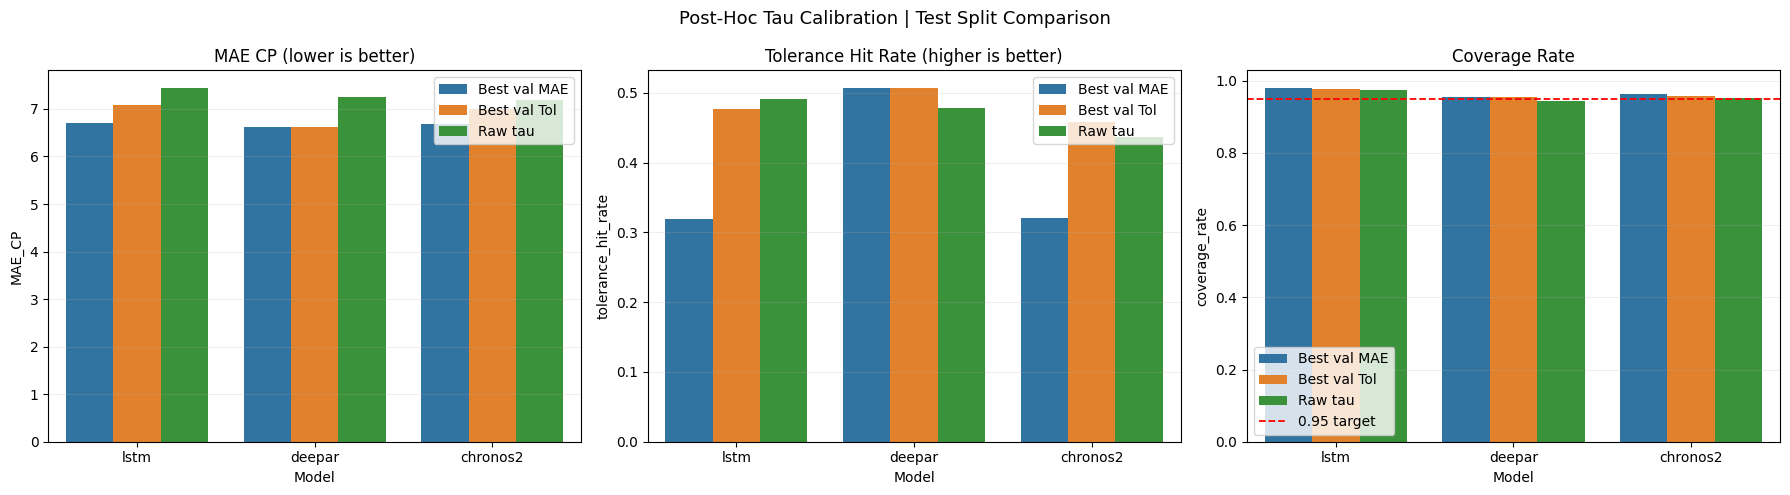

In [9]:
plot_rows = best_df[best_df['selected_on'].isin(['raw_test_baseline', 'best_val_mae_cp', 'best_val_tolerance_hit_rate'])].copy()
label_map = {
    'raw_test_baseline': 'Raw tau',
    'best_val_mae_cp': 'Best val MAE',
    'best_val_tolerance_hit_rate': 'Best val Tol',
}
plot_rows['selection_label'] = plot_rows['selected_on'].map(label_map)

metric_specs = [
    ('MAE_CP', 'MAE CP (lower is better)'),
    ('tolerance_hit_rate', 'Tolerance Hit Rate (higher is better)'),
    ('coverage_rate', 'Coverage Rate'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title) in zip(axes, metric_specs):
    sns.barplot(data=plot_rows, x='model', y=metric, hue='selection_label', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.2)
    if metric == 'coverage_rate':
        ax.axhline(0.95, color='red', linestyle='--', linewidth=1.3, label='0.95 target')
        ax.legend(loc='best')
    else:
        ax.legend(loc='best')

fig.suptitle('Post-Hoc Tau Calibration | Test Split Comparison', fontsize=13)
plt.tight_layout()
plot_path = PLOTS_DIR / 'tau_calibration_test_comparison.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
print('Saved plot:', plot_path)
plt.show()


Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/tau_calibration_all_techniques_heatmaps.png


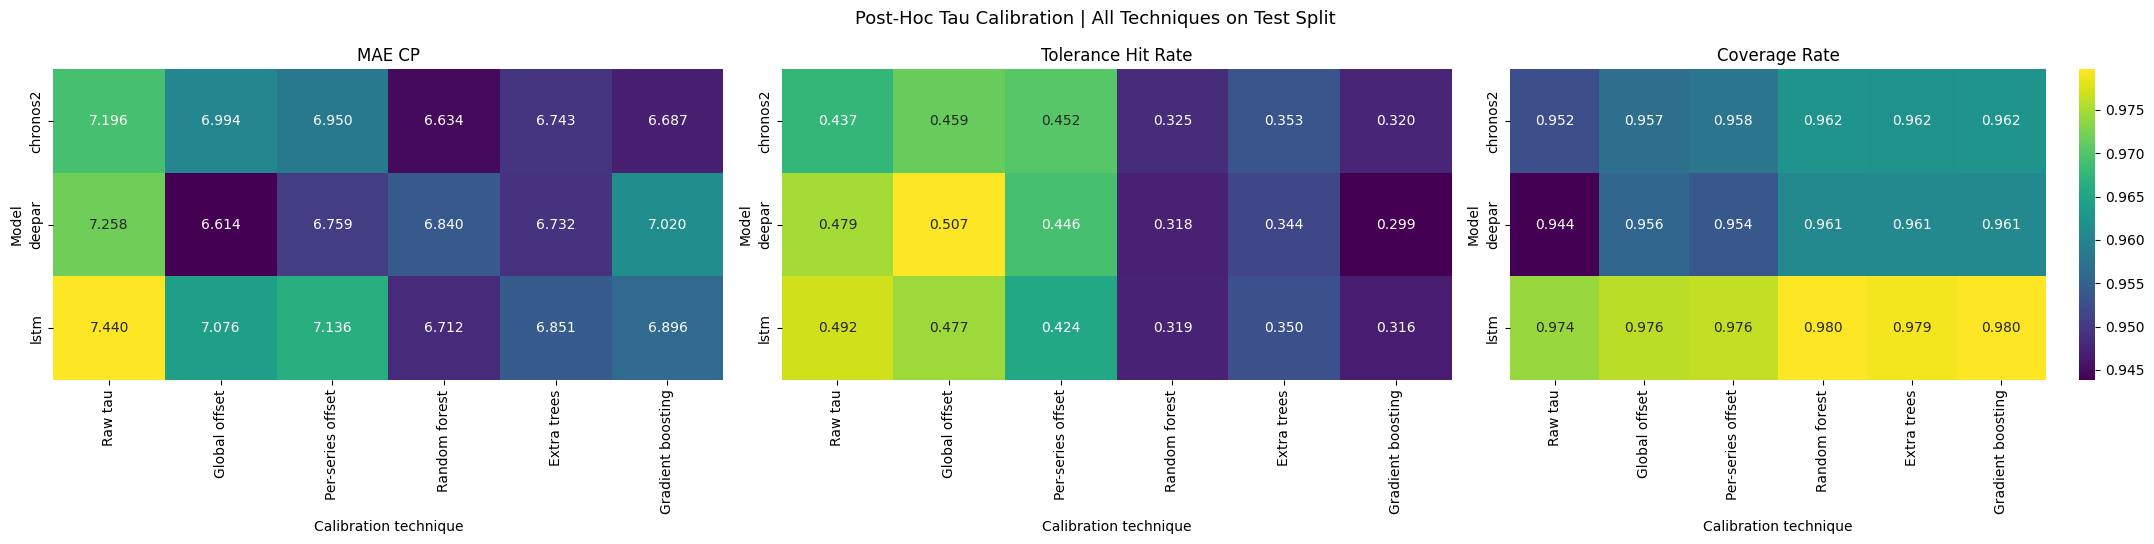

In [10]:
test_rows = summary_df[summary_df['split'] == 'test'].copy()
calibrator_order = [
    'raw_tau',
    'global_median_offset',
    'per_series_median_offset',
    'random_forest',
    'extra_trees',
    'gradient_boosting',
]
label_map = {
    'raw_tau': 'Raw tau',
    'global_median_offset': 'Global offset',
    'per_series_median_offset': 'Per-series offset',
    'random_forest': 'Random forest',
    'extra_trees': 'Extra trees',
    'gradient_boosting': 'Gradient boosting',
}
test_rows['calibrator_label'] = pd.Categorical(test_rows['calibrator'].map(label_map), categories=[label_map[c] for c in calibrator_order], ordered=True)
metric_specs = [
    ('MAE_CP', 'MAE CP'),
    ('tolerance_hit_rate', 'Tolerance Hit Rate'),
    ('coverage_rate', 'Coverage Rate'),
]
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))
for ax, (metric, title) in zip(axes, metric_specs):
    pivot = test_rows.pivot(index='model', columns='calibrator_label', values=metric)
    pivot = pivot[[label_map[c] for c in calibrator_order if label_map[c] in pivot.columns]]
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax, cbar=(metric == 'coverage_rate'))
    ax.set_title(title)
    ax.set_xlabel('Calibration technique')
    ax.set_ylabel('Model')
fig.suptitle('Post-Hoc Tau Calibration | All Techniques on Test Split', fontsize=13)
plt.tight_layout()
all_plot_path = PLOTS_DIR / 'tau_calibration_all_techniques_heatmaps.png'
fig.savefig(all_plot_path, dpi=160, bbox_inches='tight')
print('Saved plot:', all_plot_path)
plt.show()


Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/tau_calibration_feature_importances.png


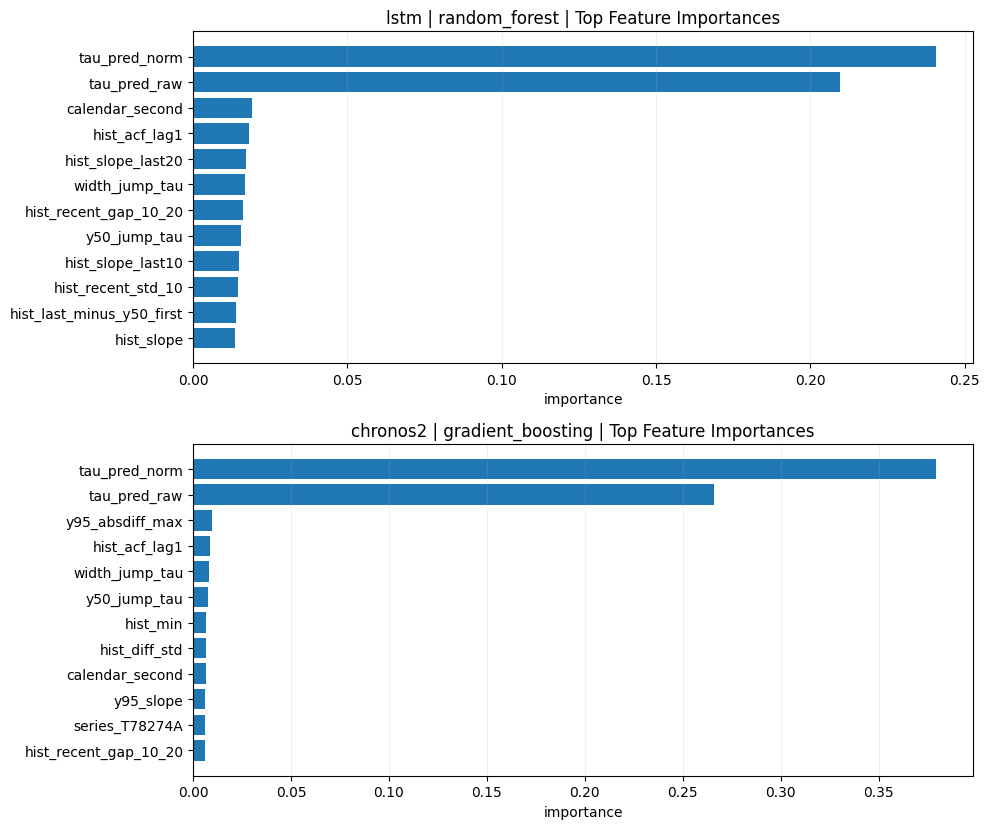

In [11]:
mae_selected = best_df[best_df['selected_on'] == 'best_val_mae_cp'][['model', 'calibrator']].copy()
feat_plot_df = feat_df.merge(mae_selected, on=['model', 'calibrator'], how='inner')
if feat_plot_df.empty:
    print('No feature-based best_val_mae_cp models were selected, so no importance plot was generated.')
else:
    models = feat_plot_df['model'].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(models), 1, figsize=(10, 4.2 * len(models)), squeeze=False)
    for idx, model_name in enumerate(models):
        ax = axes[idx][0]
        sub = feat_plot_df[feat_plot_df['model'] == model_name].head(12).sort_values('importance', ascending=True)
        ax.barh(sub['feature'], sub['importance'])
        calibrator_name = sub['calibrator'].iloc[-1]
        ax.set_title(f'{model_name} | {calibrator_name} | Top Feature Importances')
        ax.set_xlabel('importance')
        ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    feat_plot_path = PLOTS_DIR / 'tau_calibration_feature_importances.png'
    fig.savefig(feat_plot_path, dpi=160, bbox_inches='tight')
    print('Saved plot:', feat_plot_path)
    plt.show()
